# **Keşifçi Veri Analizi (Exploratory Data Analysis - EDA)**

###  Kütüphanelerin Yüklenmesi

In [11]:
# temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

#istatistik kütüphaneleri
from scipy import stats
import warnings

# ayarlar
warnings.filterwarnings('ignore') # uyarı mesajlarını kapatır
pd.set_option('display.max_columns', 50)# büyük veri de gelecek columm sayısını sınırlar
pd.set_option('display.max_rows', None)# satırı sınırlar
pd.set_option('display.float_format', lambda x: '%.2f' % x)#ekranda virgülden sonra kaç basamak

#Grafik stili ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize']= (12,8)
plt.rcParams['font.size']= 12

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

print(f'Seaborn version: {sns.__version__}')

Tüm kütüphaneler başarıyla yüklendi
Pandas version: 2.2.2
Numpy version: 2.0.2
Seaborn version: 0.13.2


## Veri yükleme

In [46]:
df = pd.read_csv('/AB_NYC_2019.csv')

print('Airbnb NYC Dataset')
print('='*50)
print(f'Boyut : {df.shape[0]} satır, {df.shape[1]} sütun')
print('='*50)
print(f'Bellek kullanımı: {df.memory_usage(deep=True).sum()/1024:.2f} KB')


Airbnb NYC Dataset
Boyut : 48895 satır, 16 sütun
Bellek kullanımı: 21791.06 KB


In [47]:
#ilk beş satır yaazdırma
df.head() # parantez içine değer vermezsen default beş satır yazdırır

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [48]:
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365


In [49]:
# son 5 satırı bastırıyor
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.68,-73.95,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70,-73.93,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81,-73.95,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.76,-73.99,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76,-73.99,Private room,90,7,0,NaN,NaN,1,23


In [50]:
df.tail(2)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.76,-73.99,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76,-73.99,Private room,90,7,0,NaN,NaN,1,23


In [51]:
df.sample(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
33601,26594746,Modern Williamsburg Apartment with Manhattan V...,9685952,Ari,Brooklyn,Williamsburg,40.71,-73.96,Entire home/apt,180,2,3,2018-08-05,0.25,1,0
43855,33909633,"Amazing 3 Bed Apt, Less than 5 mins to Manhattan",251229393,Rafu,Queens,Long Island City,40.75,-73.93,Entire home/apt,129,1,3,2019-06-14,1.70,2,95
6168,4512093,manhattan (UWS) townhouse,11760806,Raj,Manhattan,Upper West Side,40.80,-73.97,Private room,299,1,1,2019-05-23,0.64,1,88
23303,18871734,Best of Brooklyn - Williamsburg 2 Bed/2 Bath Apt,13096043,David,Brooklyn,Williamsburg,40.72,-73.97,Entire home/apt,250,4,40,2019-07-06,1.58,1,41
43586,33740789,Spacious bedroom with washer and dryer unit.,144863350,Keith,Manhattan,Harlem,40.81,-73.95,Private room,51,1,12,2019-05-15,4.34,1,0


### **Veri Tipleri ve Temel İstatistikler**

In [52]:
print('Veri tipleri')
print('='*40)
dtype_df= pd.DataFrame({
    'sütun': df.columns,
    'veri tipi': df.dtypes.values,
    'null değeri':df.isnull().sum().values,
    'null oranı(%)': (df.isnull().sum().values/len(df)*100).round(2),
    'unıque': df.nunique().values
})

print(dtype_df.to_string(index=False))




Veri tipleri
                         sütun veri tipi  null değeri  null oranı(%)  unıque
                            id     int64            0           0.00   48895
                          name    object           16           0.03   47905
                       host_id     int64            0           0.00   37457
                     host_name    object           21           0.04   11452
           neighbourhood_group    object            0           0.00       5
                 neighbourhood    object            0           0.00     221
                      latitude   float64            0           0.00   19048
                     longitude   float64            0           0.00   14718
                     room_type    object            0           0.00       3
                         price     int64            0           0.00     674
                minimum_nights     int64            0           0.00     109
             number_of_reviews     int64            0          

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [54]:
df.shape

(48895, 16)

In [55]:
#  Sayısal değişkenlerie ilgili temel istatistikler
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.00,19017143.24,10983108.39,2539.00,9471945.00,19677284.00,29152178.50,36487245.00
host_id,48895.00,67620010.65,78610967.03,2438.00,7822033.00,30793816.00,107434423.00,274321313.00
latitude,48895.00,40.73,0.05,40.50,40.69,40.72,40.76,40.91
longitude,48895.00,-73.95,0.05,-74.24,-73.98,-73.96,-73.94,-73.71
price,48895.00,152.72,240.15,0.00,69.00,106.00,175.00,10000.00
minimum_nights,48895.00,7.03,20.51,1.00,1.00,3.00,5.00,1250.00
number_of_reviews,48895.00,23.27,44.55,0.00,1.00,5.00,24.00,629.00
reviews_per_month,38843.00,1.37,1.68,0.01,0.19,0.72,2.02,58.50
calculated_host_listings_count,48895.00,7.14,32.95,1.00,1.00,1.00,2.00,327.00
availability_365,48895.00,112.78,131.62,0.00,0.00,45.00,227.00,365.00


In [56]:
#kategorik  değişkenlerin temel istatistikleri
df.describe(include=['object','category']).T

,count,unique,top,freq
name,48879,47905,Hillside Hotel,18
host_name,48874,11452,Michael,417
neighbourhood_group,48895,5,Manhattan,21661
neighbourhood,48895,221,Williamsburg,3920
room_type,48895,3,Entire home/apt,25409
last_review,38843,1764,2019-06-23,1413


In [57]:
# Değişkenler türlerini ayır
sayisal_sutunlar = df.select_dtypes(include=['int64', 'float64']).columns
kategorik_sutunlar = df.select_dtypes(include=['object', 'category']).columns

### **Eksik Veri Analizi**

In [58]:
eksik =df.isnull().sum()
eksik_oranı=(eksik/len(df)*100).round(2)
eksik_df=pd.concat([eksik,eksik_oranı],axis=1)
eksik_df.columns=["eksik_sayı","eksik_oran"]
eksik_df.sort_values("eksik_oran",ascending=False)

,eksik_sayı,eksik_oran
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03
neighbourhood_group,0,0.00
neighbourhood,0,0.00
id,0,0.00
host_id,0,0.00
longitude,0,0.00
latitude,0,0.00


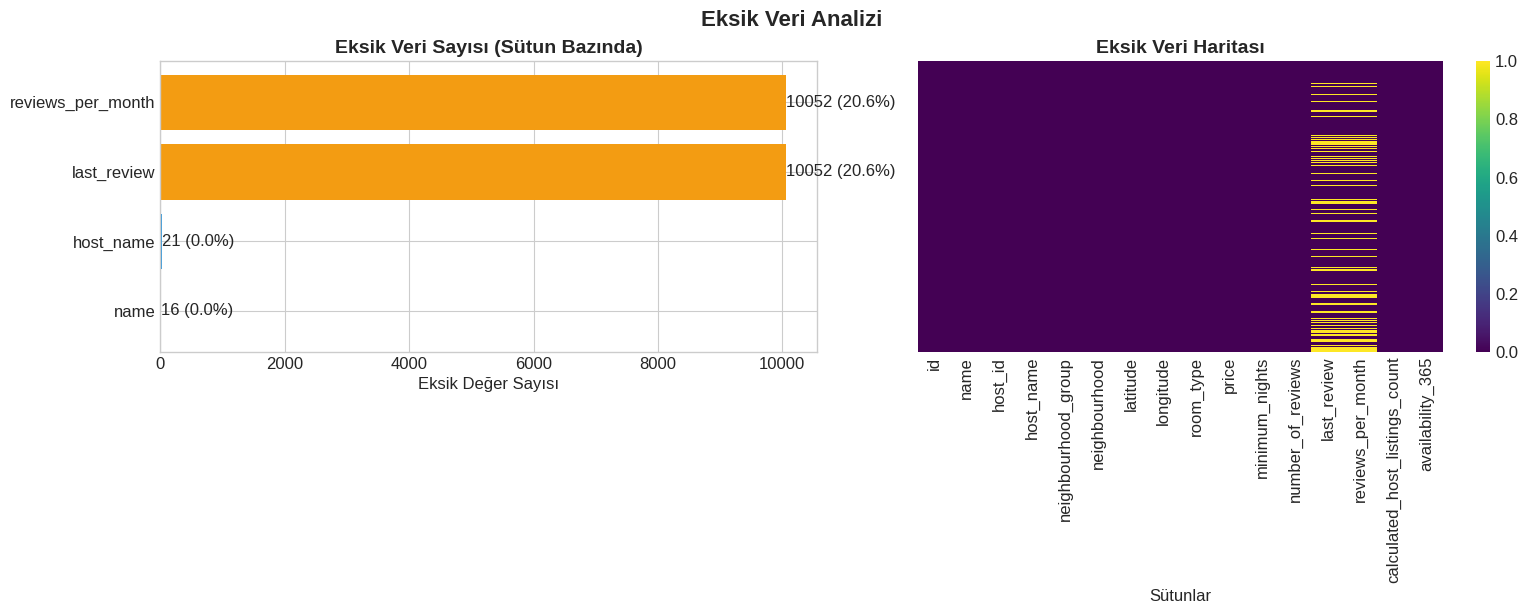

In [59]:
# Eksik veri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
eksik_olan = df.isnull().sum()
eksik_olan = eksik_olan[eksik_olan > 0].sort_values(ascending=True)

colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
          for x in (eksik_olan / len(df) * 100)]

axes[0].barh(eksik_olan.index, eksik_olan.values, color=colors)
axes[0].set_title('Eksik Veri Sayısı (Sütun Bazında)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eksik Değer Sayısı')
for i, (val, col) in enumerate(zip(eksik_olan.values, eksik_olan.index)):
    axes[0].text(val + 1, i, f'{val} ({val/len(df)*100:.1f}%)', va='center')

# Heatmap
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis',
            ax=axes[1])
axes[1].set_title('Eksik Veri Haritası', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sütunlar')

plt.tight_layout()
plt.suptitle('Eksik Veri Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.show()

###  Eksik Veri Stratejileri



In [63]:
df_temiz = df.copy()

In [64]:
rpm_medyan = df_temiz['reviews_per_month'].median()

df_temiz['reviews_per_month'].fillna(rpm_medyan, inplace=True)

In [65]:
host_mode = df_temiz['host_name'].mode()[0]

df_temiz['host_name'].fillna(host_mode, inplace=True)

In [66]:
name_mode = df_temiz['name'].mode()[0]

df_temiz['name'].fillna(name_mode, inplace=True)

In [67]:
df_temiz['last_review'].fillna(method='ffill', inplace=True)

In [68]:
df_temiz.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [71]:
# Kategorik eksik verileri mode (en sık görülen değer) ile doldurma

host_mode = df_temiz['host_name'].mode()[0]
df_temiz['host_name'].fillna(host_mode, inplace=True)

name_mode = df_temiz['name'].mode()[0]
df_temiz['name'].fillna(name_mode, inplace=True)

In [79]:
# last_review sütunundaki eksik değerleri kategoriye çevirme

df_temiz['last_review'] = df_temiz['last_review'].astype(str)

df_temiz['last_review'].replace('nan', 'No Review', inplace=True)

## **Tek değişkenli analiz**

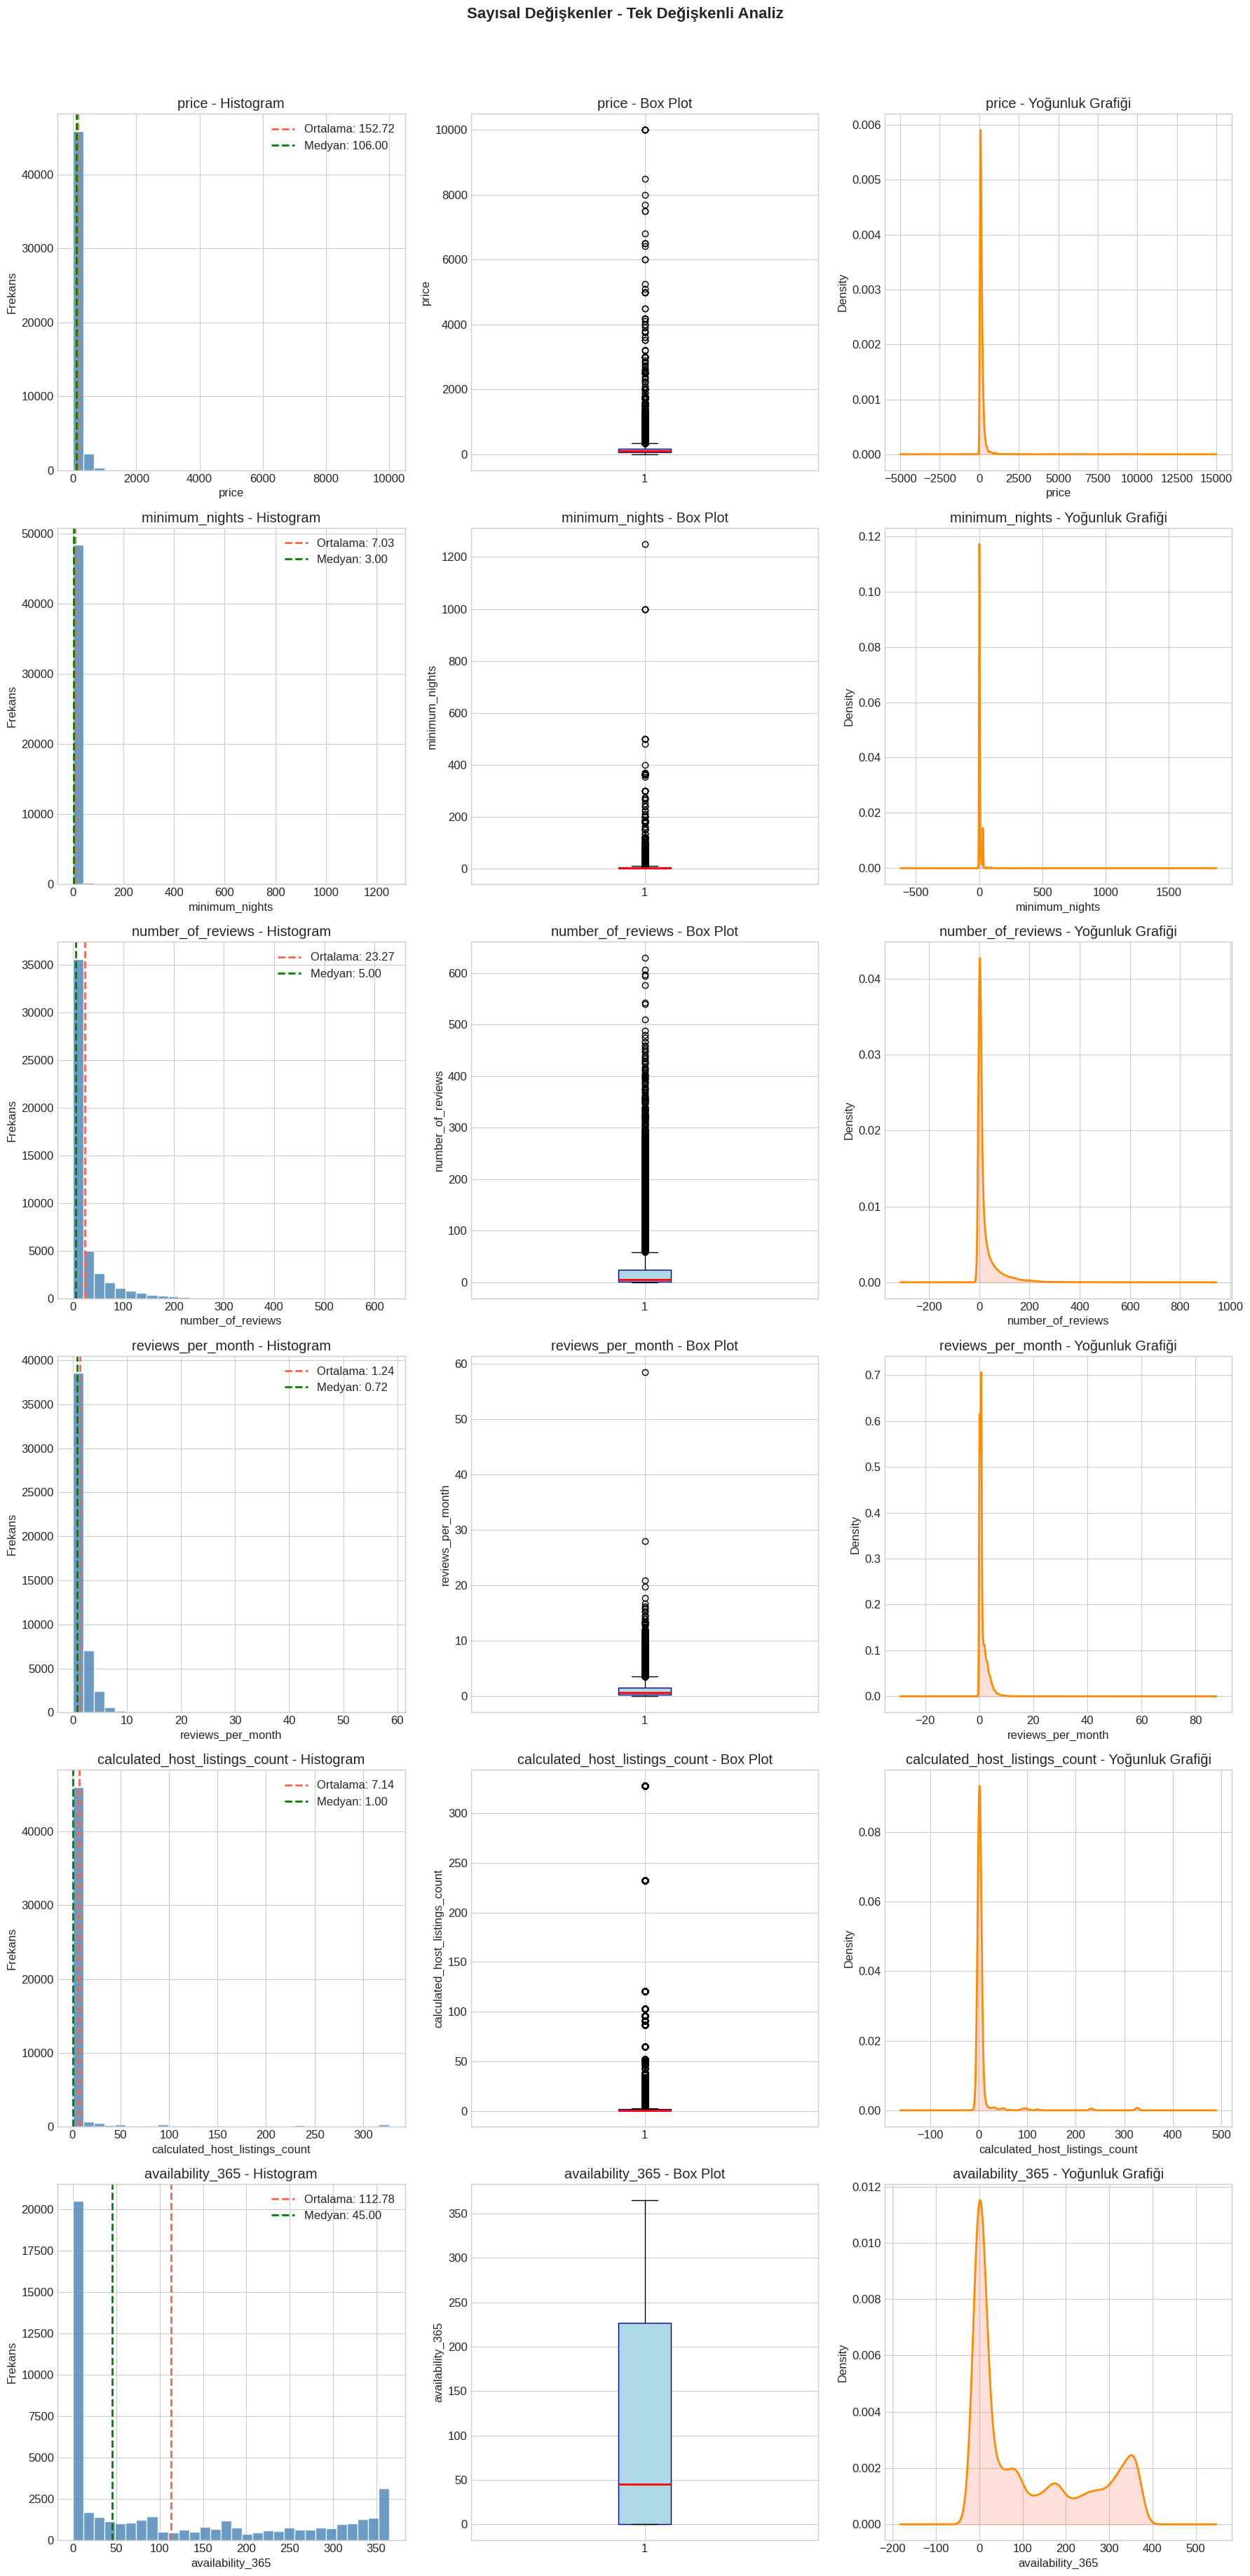

In [75]:
# Sayısal değişkenler - Tek değişkenli analiz

sayisal_kolonlar = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

fig, axes = plt.subplots(len(sayisal_kolonlar), 3, figsize=(18, 6*len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):

    veri = df_temiz[kolon].dropna()

    # Histogram
    axes[i,0].hist(veri, bins=30,
                   color="steelblue",
                   edgecolor='white',
                   alpha=0.8)

    axes[i,0].axvline(veri.mean(),
                      color='tomato',
                      linestyle='dashed',
                      linewidth=2,
                      label=f'Ortalama: {veri.mean():.2f}')

    axes[i,0].axvline(veri.median(),
                      color='green',
                      linestyle='dashed',
                      linewidth=2,
                      label=f'Medyan: {veri.median():.2f}')

    axes[i,0].set_title(f'{kolon} - Histogram')
    axes[i,0].legend()
    axes[i,0].set_xlabel(kolon)
    axes[i,0].set_ylabel('Frekans')

    # Box Plot
    axes[i,1].boxplot(veri,
                      vert=True,
                      patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='navy'),
                      medianprops=dict(color='red', linewidth=2))

    axes[i,1].set_title(f'{kolon} - Box Plot')
    axes[i,1].set_ylabel(kolon)

    # KDE Plot
    veri.plot.kde(ax=axes[i,2],
                  color='darkorange',
                  linewidth=2)

    axes[i,2].fill_between(
        axes[i,2].lines[0].get_xdata(),
        axes[i,2].lines[0].get_ydata(),
        color='tomato',
        alpha=0.2
    )

    axes[i,2].set_title(f'{kolon} - Yoğunluk Grafiği')
    axes[i,2].set_xlabel(kolon)

plt.suptitle('Sayısal Değişkenler - Tek Değişkenli Analiz',
             fontsize=16,
             fontweight='bold',
             y=1.02)

plt.tight_layout()
plt.show()

In [76]:
# istatiksel özet tablo
print('Sayısal Değişkenler detaylı İstatistikler:')
print('='*70)


for kolon in sayisal_kolonlar :
  veri=df_temiz[kolon].dropna()
  print(f'\n * {kolon.upper()}')
  print(f'Ortalama: {veri.mean():.2f}')
  print(f'Medyan: {veri.median():.2f}')
  print(f'Standart Sapma: {veri.std():.2f}')
  print(f'Minimum: {veri.min():.2f}')
  print(f'Maksimum: {veri.max():.2f}')
  print(f'Varyans: {veri.var():.2f}')
  print(f'Skewness(Çarpıklık): {veri.skew():.2f}')
  print(f'Kurtosis(Basıklık): {veri.kurtosis():.2f}')
  print(f'IQR: {veri.quantile(0.75)-veri.quantile(0.25):.2f}')
  print('='*70)

Sayısal Değişkenler detaylı İstatistikler:

 * PRICE
Ortalama: 152.72
Medyan: 106.00
Standart Sapma: 240.15
Minimum: 0.00
Maksimum: 10000.00
Varyans: 57674.03
Skewness(Çarpıklık): 19.12
Kurtosis(Basıklık): 585.67
IQR: 106.00

 * MINIMUM_NIGHTS
Ortalama: 7.03
Medyan: 3.00
Standart Sapma: 20.51
Minimum: 1.00
Maksimum: 1250.00
Varyans: 420.68
Skewness(Çarpıklık): 21.83
Kurtosis(Basıklık): 854.07
IQR: 4.00

 * NUMBER_OF_REVIEWS
Ortalama: 23.27
Medyan: 5.00
Standart Sapma: 44.55
Minimum: 0.00
Maksimum: 629.00
Varyans: 1984.75
Skewness(Çarpıklık): 3.69
Kurtosis(Basıklık): 19.53
IQR: 23.00

 * REVIEWS_PER_MONTH
Ortalama: 1.24
Medyan: 0.72
Standart Sapma: 1.52
Minimum: 0.01
Maksimum: 58.50
Varyans: 2.31
Skewness(Çarpıklık): 3.60
Kurtosis(Basıklık): 52.10
IQR: 1.30

 * CALCULATED_HOST_LISTINGS_COUNT
Ortalama: 7.14
Medyan: 1.00
Standart Sapma: 32.95
Minimum: 1.00
Maksimum: 327.00
Varyans: 1085.87
Skewness(Çarpıklık): 7.93
Kurtosis(Basıklık): 67.55
IQR: 1.00

 * AVAILABILITY_365
Ortalama: 112.78


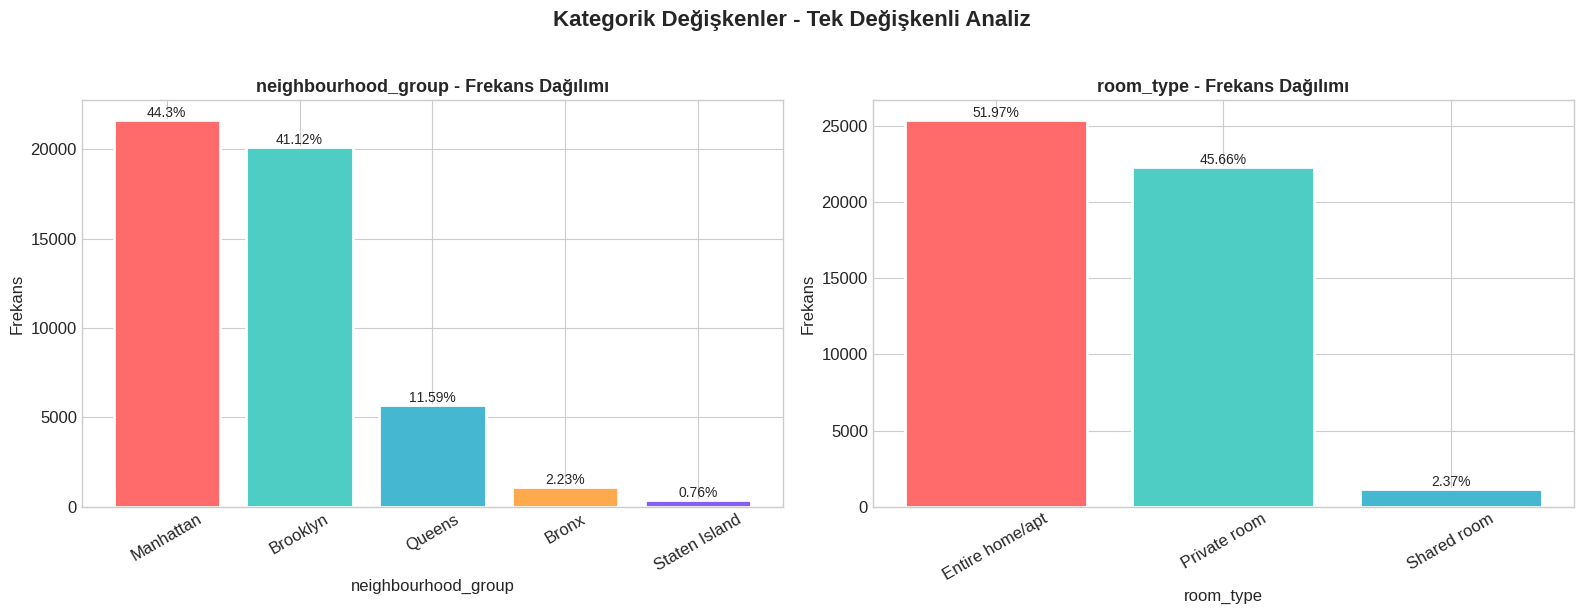

In [77]:
# Kategorik değişkenler - Tek değişkenli analiz

kategorik_kolonlar = ['neighbourhood_group', 'room_type']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes = axes.flatten()

renkler = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA94D', '#845EF7', '#F06595']

for i, kolon in enumerate(kategorik_kolonlar):
    degerler = df_temiz[kolon].value_counts()
    yuzde = (degerler / len(df_temiz) * 100).round(2)

    bars = axes[i].bar(
        degerler.index.astype(str),
        degerler.values,
        color=renkler[:len(degerler)],
        edgecolor='white',
        linewidth=2
    )

    axes[i].set_title(f'{kolon} - Frekans Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(kolon)
    axes[i].set_ylabel('Frekans')
    axes[i].tick_params(axis='x', rotation=30)

    for bar, pct in zip(bars, yuzde.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{pct}%',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.suptitle('Kategorik Değişkenler - Tek Değişkenli Analiz',
             fontsize=16,
             fontweight='bold',
             y=1.02)

plt.tight_layout()
plt.show()

### Çift Değişkenli Analiz

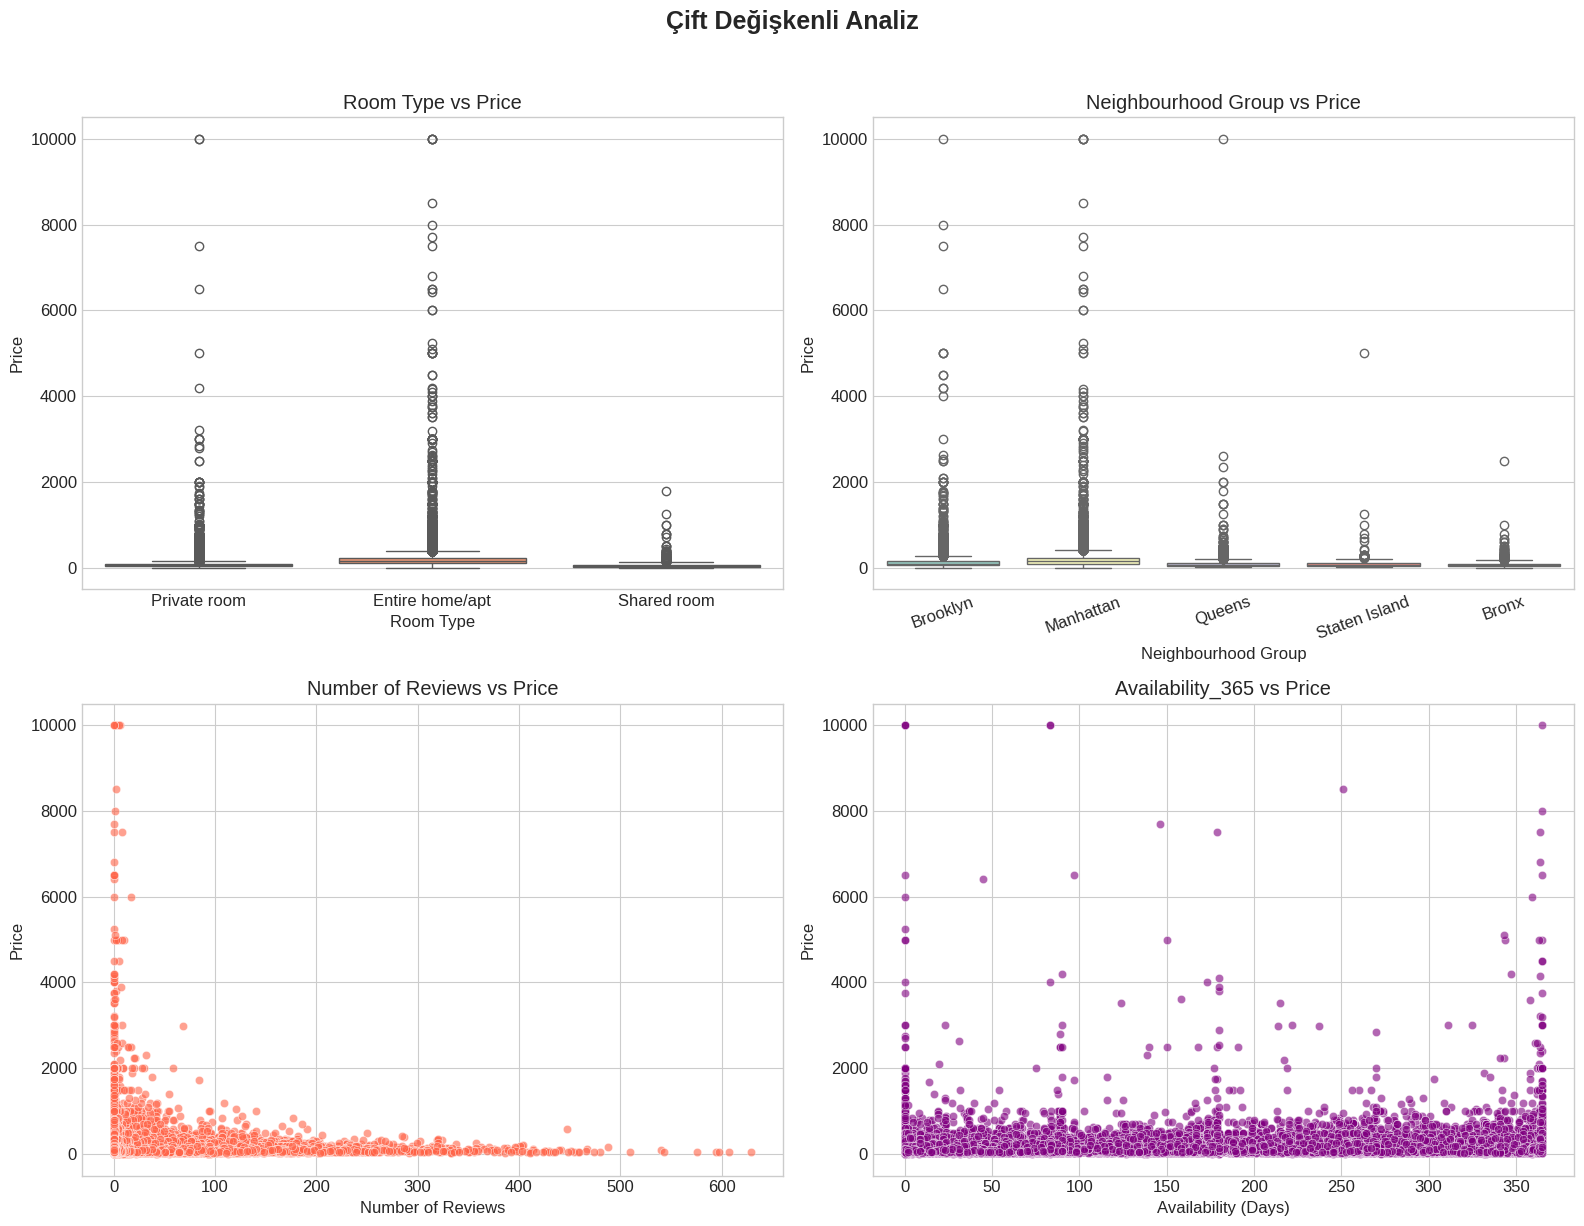

In [78]:
# Çift değişkenli analiz

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Room Type vs Price
sns.boxplot(
    data=df_temiz,
    x='room_type',
    y='price',
    ax=axes[0,0],
    palette='Set2'
)

axes[0,0].set_title('Room Type vs Price')
axes[0,0].set_xlabel('Room Type')
axes[0,0].set_ylabel('Price')


# 2. Neighbourhood Group vs Price
sns.boxplot(
    data=df_temiz,
    x='neighbourhood_group',
    y='price',
    ax=axes[0,1],
    palette='Set3'
)

axes[0,1].set_title('Neighbourhood Group vs Price')
axes[0,1].set_xlabel('Neighbourhood Group')
axes[0,1].set_ylabel('Price')
axes[0,1].tick_params(axis='x', rotation=20)


# 3. Number of Reviews vs Price
sns.scatterplot(
    data=df_temiz,
    x='number_of_reviews',
    y='price',
    ax=axes[1,0],
    color='tomato',
    alpha=0.6
)

axes[1,0].set_title('Number of Reviews vs Price')
axes[1,0].set_xlabel('Number of Reviews')
axes[1,0].set_ylabel('Price')


# 4. Availability vs Price
sns.scatterplot(
    data=df_temiz,
    x='availability_365',
    y='price',
    ax=axes[1,1],
    color='purple',
    alpha=0.6
)

axes[1,1].set_title('Availability_365 vs Price')
axes[1,1].set_xlabel('Availability (Days)')
axes[1,1].set_ylabel('Price')


plt.suptitle(
    'Çift Değişkenli Analiz',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

## Kategorik vs Kategorik

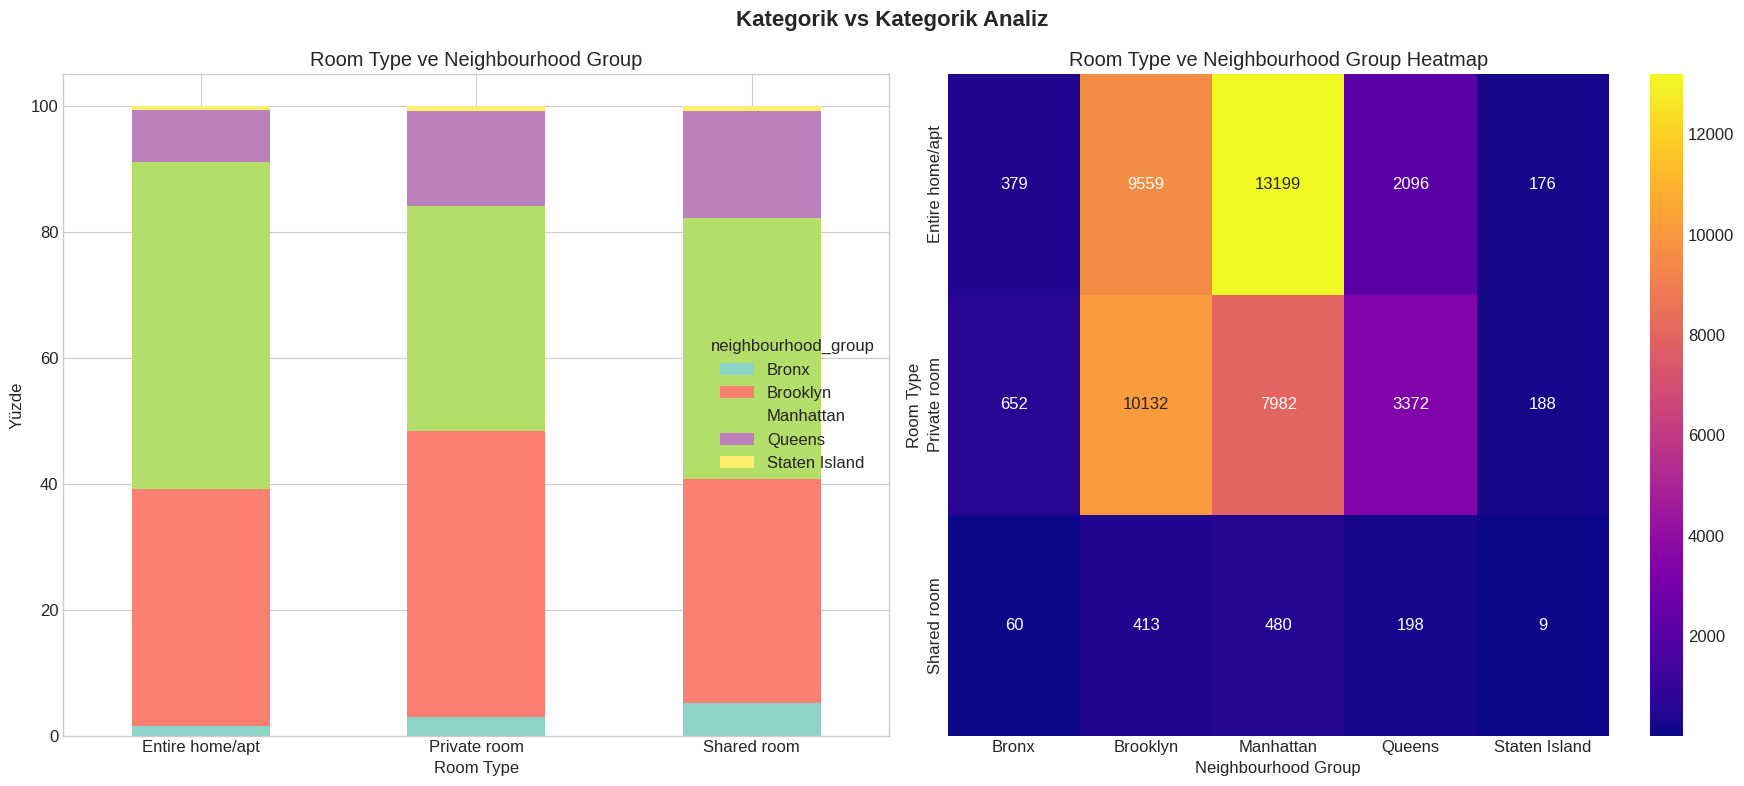

In [81]:
# Kategorik vs Kategorik Analiz

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Room Type ve Neighbourhood Group ilişkisi
ct = pd.crosstab(
    df_temiz['room_type'],
    df_temiz['neighbourhood_group'],
    normalize='index'
) * 100

ct.plot(kind='bar',
        stacked=True,
        ax=axes[0],
        colormap='Set3')

axes[0].set_title('Room Type ve Neighbourhood Group')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Yüzde')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)


# Heatmap
ct2 = pd.crosstab(
    df_temiz['room_type'],
    df_temiz['neighbourhood_group']
)

sns.heatmap(
    ct2,
    annot=True,
    fmt='d',
    cmap='plasma',
    ax=axes[1]
)

axes[1].set_title('Room Type ve Neighbourhood Group Heatmap')
axes[1].set_xlabel('Neighbourhood Group')
axes[1].set_ylabel('Room Type')

plt.suptitle('Kategorik vs Kategorik Analiz',
             fontsize=16,
             fontweight='bold')

plt.tight_layout()
plt.show()

## Kategorik vs Numerik

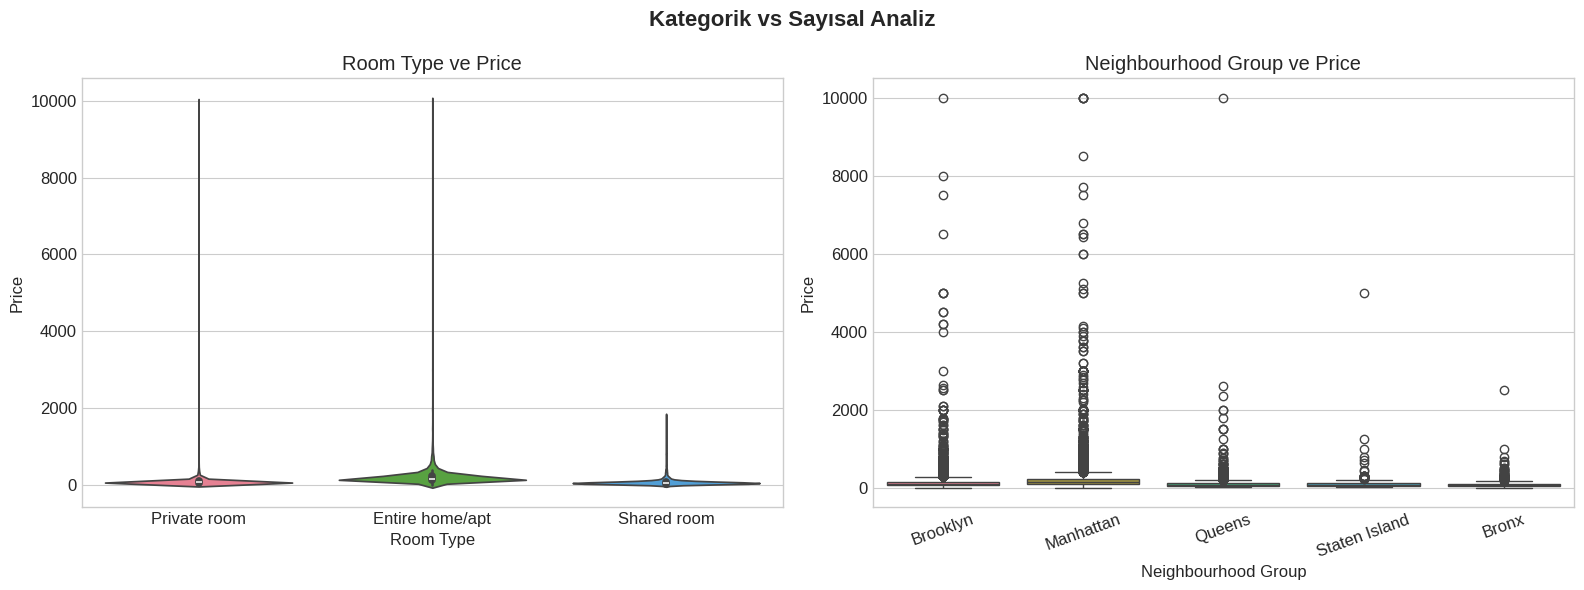

In [83]:
# Kategorik vs Sayısal Analiz

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Room Type vs Price
sns.violinplot(
    data=df_temiz,
    x='room_type',
    y='price',
    ax=axes[0],
    palette='husl'
)

axes[0].set_title('Room Type ve Price')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Price')


# Neighbourhood Group vs Price
sns.boxplot(
    data=df_temiz,
    x='neighbourhood_group',
    y='price',
    ax=axes[1],
    palette='husl'
)

axes[1].set_title('Neighbourhood Group ve Price')
axes[1].set_xlabel('Neighbourhood Group')
axes[1].set_ylabel('Price')

axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Kategorik vs Sayısal Analiz',
             fontsize=16,
             fontweight='bold')

plt.tight_layout()
plt.show()